# Style Model Eval and Loss Plots

This notebook plots eval CSVs (ADP/SL/WP/Random/RLCard) and training losses from logs.csv.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")


In [2]:
def find_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for cand in candidates:
        if (cand / "douzero_checkpoints").exists():
            return cand
    return start

repo_root = find_repo_root(Path.cwd())
logs_dir = repo_root / "douzero_checkpoints" / "style" / "style_model" / "logs"

eval_files = {
    "adp": logs_dir / "adp_eval.csv",
    "sl": logs_dir / "sl_eval.csv",
    "wp": logs_dir / "wp_eval.csv",
    "random": logs_dir / "random_eval.csv",
    "rlcard": logs_dir / "rlcard_eval.csv",
}

logs_csv = logs_dir / "logs.csv"

print("Repo root:", repo_root)
print("Logs dir:", logs_dir)
for name, path in eval_files.items():
    print(f"{name}: {path.exists()} -> {path}")
print("training logs:", logs_csv.exists(), "->", logs_csv)

Repo root: /home/users/yf201/Code/RL-Project/StyleDou
Logs dir: /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs
adp: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/adp_eval.csv
sl: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/sl_eval.csv
wp: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/wp_eval.csv
random: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/random_eval.csv
rlcard: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/rlcard_eval.csv
training logs: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/logs.csv


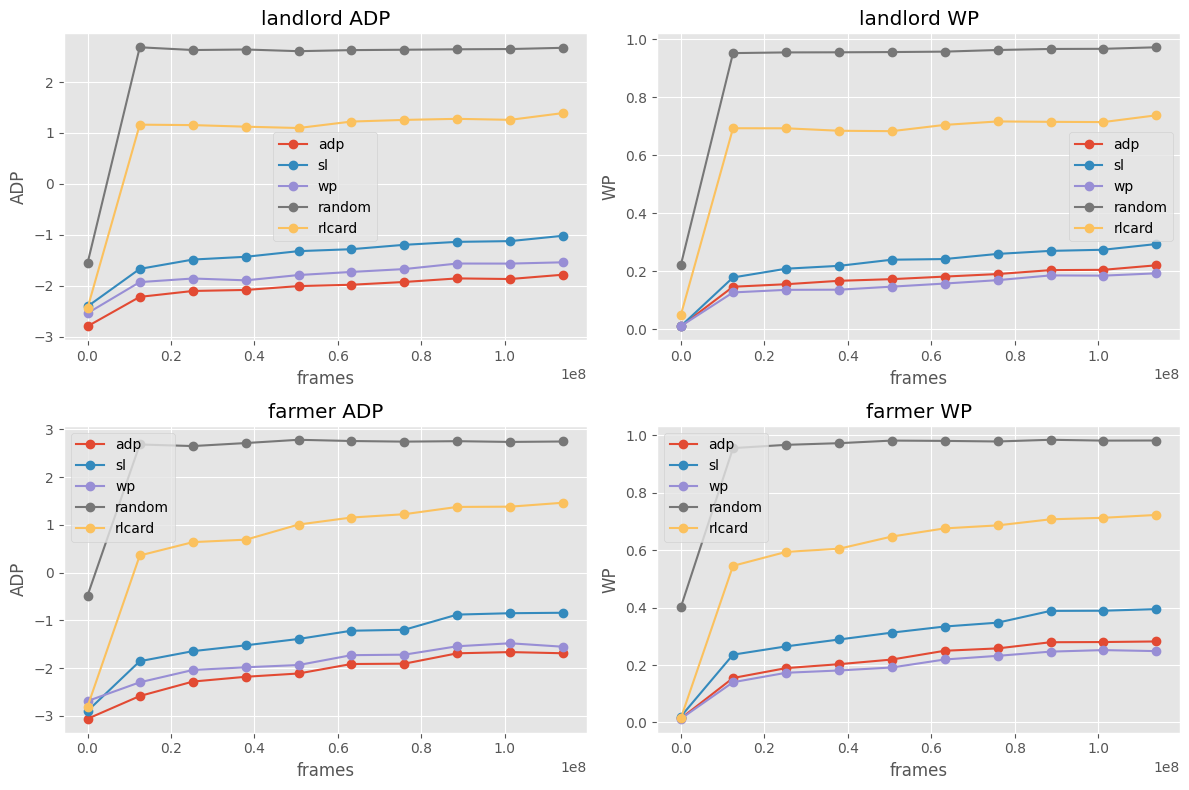

In [3]:
def load_eval_csv(path):
    if not path.exists():
        return None
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    return df

def plot_eval_grid(eval_data):
    roles = ["landlord", "farmer"]
    metrics = [("adp", "ADP"), ("wp", "WP")]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
    for row_idx, role in enumerate(roles):
        for col_idx, (metric_key, metric_label) in enumerate(metrics):
            ax = axes[row_idx, col_idx]
            has_series = False
            for test_type, df in eval_data.items():
                if df is None or df.empty:
                    continue
                if "role" not in df.columns:
                    continue
                role_df = df[df["role"] == role].copy()
                if role_df.empty:
                    continue
                if role == "landlord":
                    metric_col = f"{metric_key}_landlord"
                else:
                    metric_col = f"{metric_key}_farmer"
                if metric_col not in role_df.columns:
                    continue
                if "frames" in role_df.columns:
                    x = role_df["frames"]
                    x_label = "frames"
                else:
                    x = range(len(role_df))
                    x_label = "index"
                ax.plot(x, role_df[metric_col], marker="o", label=test_type)
                has_series = True
            ax.set_title(f"{role} {metric_label}")
            ax.set_xlabel(x_label)
            ax.set_ylabel(metric_label)
            if has_series:
                ax.legend()
            else:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    fig.tight_layout()
    plt.show()

eval_data = {test_type: load_eval_csv(path) for test_type, path in eval_files.items()}
plot_eval_grid(eval_data)

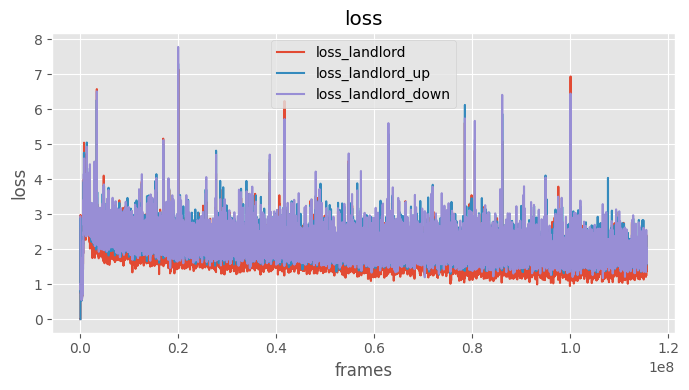

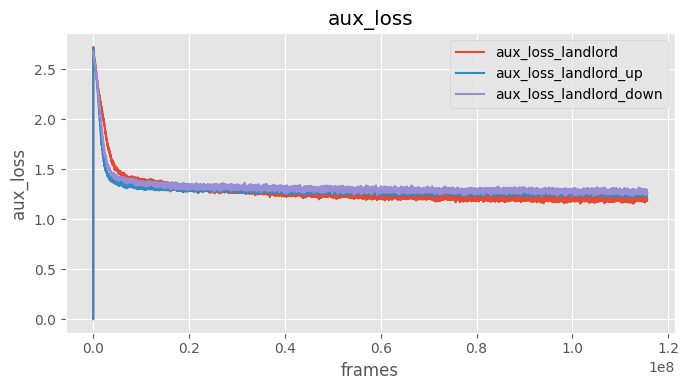

In [4]:
def load_training_logs(path: Path):
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as handle:
        first_line = handle.readline().strip()
    header = None
    if first_line.startswith("#"):
        header = [c.strip() for c in first_line.lstrip("# ").split(",")]
    if header:
        df = pd.read_csv(path, comment="#", names=header)
    else:
        df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    return df

train_df = load_training_logs(logs_csv)
if train_df is None or train_df.empty:
    print("logs.csv not found or empty")
else:
    if "frames" in train_df.columns:
        x = train_df["frames"]
        x_label = "frames"
    else:
        x = range(len(train_df))
        x_label = "index"

    loss_cols = [col for col in train_df.columns if col.startswith("loss_")]
    aux_cols = [col for col in train_df.columns if col.startswith("aux_loss_")]
    if not loss_cols and not aux_cols:
        loss_cols = [col for col in train_df.columns if "loss" in col]
        aux_cols = []
        for col in loss_cols[:]:
            if col.startswith("aux"):
                aux_cols.append(col)
                loss_cols.remove(col)
    if not loss_cols and not aux_cols:
        print("No loss columns found in logs.csv. Columns:")
        print(train_df.columns.tolist())
    else:
        if loss_cols:
            plt.figure(figsize=(7, 4))
            for col in loss_cols:
                series = pd.to_numeric(train_df[col], errors="coerce")
                plt.plot(x, series, label=col)
            plt.title("loss")
            plt.xlabel(x_label)
            plt.ylabel("loss")
            plt.legend()
            plt.tight_layout()
            plt.show()

        if aux_cols:
            plt.figure(figsize=(7, 4))
            for col in aux_cols:
                series = pd.to_numeric(train_df[col], errors="coerce")
                plt.plot(x, series, label=col)
            plt.title("aux_loss")
            plt.xlabel(x_label)
            plt.ylabel("aux_loss")
            plt.legend()
            plt.tight_layout()
            plt.show()